In [1]:
import numpy as np
import pandas as pd

In [2]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')

train['triage_acuity'] = pd.Categorical(train['triage_acuity'], ordered = True, categories = [1, 2, 3, 4, 5])
all_data = pd.concat([train, test], axis = 0)

In [3]:
all_data.columns

Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season',
       'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type',
       'transport_origin', 'pain_location', 'mental_status_triage',
       'chief_complaint_system', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'disposition', 'ed_los_hours', 'triage_acuity'],
      dtype='str')

In [4]:
datasets = {'train': train, 'test': test, 'combined': all_data}
datainfo = pd.DataFrame({'name': name, 'num_encounters': len(dataset)} for name, dataset in datasets.items())
print('num of encounters:')
for name, dataset in datasets.items():
    print(f'    {name}: {len(dataset)}')


num of encounters:
    train: 80000
    test: 20000
    combined: 100000


In [5]:
unique_patients = all_data['patient_id'].unique()
print('num of patients:', len(unique_patients))

datainfo['num_patients'] = datainfo['name'].map(lambda name: len(datasets[name]['patient_id'].unique()))

num of patients: 100000


In [6]:
print('num of sites:', len(all_data['site_id'].unique()))

datainfo['num_sites'] = datainfo['name'].map(lambda name: len(datasets[name]['site_id'].unique()))

num of sites: 5


In [7]:
print('num of triage nurses:', len(all_data['triage_nurse_id'].unique()))

datainfo['num_triage_nurses'] = datainfo['name'].map(lambda name: len(datasets[name]['triage_nurse_id'].unique()))

num of triage nurses: 50


In [8]:
datainfo

,name,num_encounters,num_patients,num_sites,num_triage_nurses
0,train,80000,80000,5,50
1,test,20000,20000,5,50
2,combined,100000,100000,5,50


In [9]:
acuity_counts = all_data['triage_acuity'].value_counts().sort_index()
acuity_counts

triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

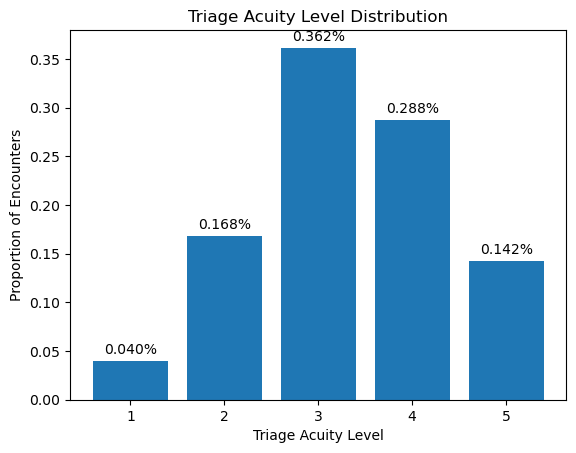

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
bar = ax.bar(acuity_counts.index, acuity_counts.values/sum(acuity_counts.values))
plt.title('Triage Acuity Level Distribution')
plt.xlabel('Triage Acuity Level')
plt.ylabel('Proportion of Encounters')
ax.bar_label(bar, fmt='%.3f%%', padding=3) 
plt.show()

In [11]:
print('avg patient age:', all_data['age'].mean())
print('patient min:', all_data['age'].min())
print('patient max:', all_data['age'].max())

avg patient age: 48.49432
patient min: 1
patient max: 94


In [12]:
print('avg patient weight:', all_data['weight_kg'].mean())
print('avg patient bmi:', all_data['bmi'].mean())

avg patient weight: 74.522865
avg patient bmi: 26.382780999999998


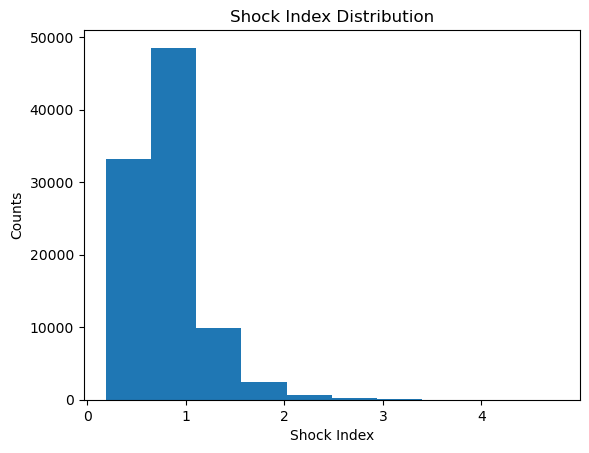

In [13]:
plt.hist(all_data['shock_index'])
plt.title('Shock Index Distribution')
plt.xlabel('Shock Index')
plt.ylabel('Counts')
plt.show()